u = [2.41317491 2.81537072 3.21756654 3.61976236 4.02195818 4.53399592]
E1 = [4.01366435 4.00499263 4.06865612 4.21946462 4.49865441 5.21745162]
u = [4.53399592 4.82634981 5.22854563 5.63074145 6.03293726 6.43513308
 6.8373289  7.23952472 7.81510989]
E2 = [0.7666578 0.7666578 0.7666578 0.7666578 0.7666578 0.7666578 0.7666578
 0.7666578 0.7666578]


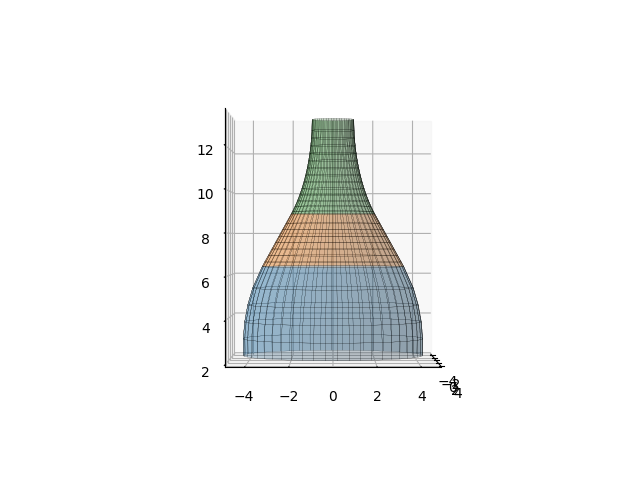

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
%matplotlib ipympl


#Rounding
dp = 2

#Bottle parameters
p = 1
a = 3.4
b = 4
theta = .7
phi = .45
w = 8.6
e = w/2
h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
d = np.sqrt(e*(e-p)/2)
c = (h*np.sin(phi)+p*np.cos(phi)-e)/(1-np.cos(phi))

P = np.array([0,a*(1+np.cos(theta)),d+h-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),d+b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

X = np.array([0,e*np.cos(phi),d+e*np.sin(phi)])
Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])

t = np.array([
    0,
    d, 
    e*np.sin(phi)+d, 
    h-c*np.sin(phi)+d, 
    h+d, 
    h+d+a*(np.pi+theta), 
    h+d+a*(np.pi+theta)+magPQ, 
    h+d+a*(np.pi+theta)+magPQ+b*theta,
    h+2*d+a*(np.pi+theta)+magPQ+b*theta
])

u = np.linspace(0, np.max(t), 100)

ut = [0]*(len(t)-1)

for j in range(len(t)-1):
    ut[j] = int(np.max(np.argwhere(u<t[j+1])))

usplit = [u[:ut[0]],
          u[ut[0]:ut[1]+1],
          u[ut[1]:ut[2]+1],
          u[ut[2]:ut[3]+1],
          u[ut[3]:ut[4]+1],
          u[ut[4]:ut[5]+1],
          u[ut[5]:ut[6]+1],
          u[ut[6]:ut[7]+1]]

for j in range(len(ut)): #to remove annoying gaps
    l=len(usplit[j])
    usplit[j][l-1] = t[j+1]

# Set up a figure and axes
fig = plt.figure()
ax = fig.add_subplot(projection='3d',label=' ')

#Base 0
#Not canal
u = usplit[0]
r = (p+e)/2+((e-p)/2)*np.sqrt(1-(u/d-1)**2)
#rdot = -((e-p)/2)*(u/d-1)/np.sqrt(1-(u/d-1)**2)
#rddot = -((e-p)/2)/((1-(u/d-1)**2)*np.sqrt(1-(u/d-1)**2))
gamma = (0,0,u)
T = (0,0,1)
N = (0,1,0)
B = (1,0,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] + r*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] + r*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] + r*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)


#Bottle canal 1
u = usplit[1]
r = np.sqrt(e**2-(u-d)**2)
rdot = -(u-d)/np.sqrt(e**2-(u-d)**2)
rddot = -e**2*np.power((e**2-(u-d)**2),-1.5)
E1 = (1-r*rddot-rdot**2)**2 + (rdot**2*(1-rdot**2-r*rddot)**2)/(1-rdot**2)
print('u =',u)
print('E1 =',E1)
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)


#Bottle canal 2
u = usplit[2]
r = e/np.cos(phi)-(u-d)*np.tan(phi)
rdot = -np.tan(phi)
rddot = 0
E2 = (1-r*rddot-rdot**2)**2 + (rdot**2*(1-rdot**2-r*rddot)**2)/(1-rdot**2)
print('u =',u)
print('E2 =',E2)
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)



#Bottle canal 3
u = usplit[3]
r = p+c-np.sqrt(c**2-(u-t[4])**2)
rdot = (u-t[4])/np.sqrt(c**2-(u-t[4])**2)
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)

#Handle 4
u = usplit[4]
r = p
rdot = 0
gamma = (0, a*(1+np.cos(np.pi-(u-t[4])/a)), d+h+a*np.sin(np.pi-(u-t[4])/a))
T = (0,np.sin(np.pi-(u-t[4])/a),-np.cos(np.pi-(u-t[4])/a))
N = (0,-np.cos(np.pi-(u-t[4])/a),-np.sin(np.pi-(u-t[4])/a))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)


#Handle 5
u = usplit[5]
gamma = (0,((u-t[5])/magPQ)*Q[1] + (1-(u-t[5])/magPQ)*P[1],((u-t[5])/magPQ)*Q[2] + (1-(u-t[5])/magPQ)*P[2])
T = (0,PQhat[1],PQhat[2])
N = (0,PQhat[2],-PQhat[1])
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)


#Handle 6
u = usplit[6]
gamma = (0, b+b*np.cos(np.pi-theta+(u-t[6])/b), d+b*np.sin(np.pi-theta+(u-t[6])/b))
T = (0,-np.sin(np.pi-theta+(u-t[6])/b),np.cos(np.pi-theta+(u-t[6])/b))
N = (0,np.cos(np.pi-theta+(u-t[6])/b),np.sin(np.pi-theta+(u-t[6])/b))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)

#Base 7
u = usplit[7]
r = (p+e)/2-((e-p)/2)*np.sqrt(1-((u-u[0])/d)**2)
gamma = (0,0,h+2*d+a*(np.pi+theta)+magPQ+b*theta-u)
T = (0,0,-1)
N = (0,-1,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] + r*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] + r*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] + r*(N[2]*np.cos(v)+B[2]*np.sin(v))

#ax.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)


ax.set_aspect('equal')
ax.view_init(elev=0, azim=0, roll=0)


plt.show()



In [10]:
np.power(3,2)

np.int64(9)